# HVM Latent Reconstruction

Load the best neural → VAE latent encoder from the sweep, predict `(16, 8, 8)` latents from IT
neural responses, upsample back to `(16, 34, 34)` (the FLUX VAE resolution for HVM stimuli),
then use those predicted latents to initialise FLUX img2img denoising.

**Pipeline:**
1. Load best checkpoint from `checkpoints/hvm/transformer/vae_latent_flat/`
2. Run inference on the test split → predicted flat latents
3. Denormalise → reshape to `(16, 8, 8)` → upsample to `(16, 34, 34)`
4. Use upsampled predicted latent as `init_latent` for `generate_img2img` at low strength
5. Compare against GT-latent init (upper bound) and pure-noise init (lower bound)

Stimuli are drawn from the **test split** (held-out from encoder training).

In [1]:
import sys, json
sys.path.insert(0, ".")

import numpy as np
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image, ImageDraw

from config_const import (
    CHECKPOINT_DIR, CACHE_DIR, SEED,
    HVM_VAE_LATENTS_PATH,
    HVM_SIGLIP_EMBEDDINGS_PATH, HVM_CLIP_EMBEDS_PATH,
    HVM_N_STIMULI, HVM_N_VAR, HVM_N_CAT,
    HVM_NOFIXATION_DIR, SIGLIP_DIM,
)
from generation.flux_instantx import (
    load_pipeline,
    generate_img2img,
    decode_latent,
    encode_text_embeds,
)
from generation.aperture import load_hvm_packed_aperture_mask
from encoders import TemporalTransformer, MultiHeadTransformer
from train.train_latent import (
    _load_hvm_neural,
    _hvm_stratified_split,
    build_model,
    prepare_input,
)
import argparse

## Load best checkpoint

In [2]:
CKPT_ROOT = CHECKPOINT_DIR / 'hvm' / 'transformer' / 'vae_latent_flat'
TARGET_POOL_HW = 34  # full HVM VAE resolution — change to 8 to view pooled-latent runs

rows = []
for p in CKPT_ROOT.glob('*/best.pt'):
    ckpt = torch.load(p, weights_only=True, map_location='cpu')
    args = ckpt.get('args', {})
    if args.get('pool_hw') != TARGET_POOL_HW:
        continue
    if 'lat_mean' not in ckpt:
        continue
    rows.append({
        'path': p,
        'val_cos': ckpt['metrics']['val_cos_sim'],
        'test_cos': ckpt.get('test_metrics', {}).get('test_cos_sim', float('nan')),
        'args': args,
        'ckpt': ckpt,
    })

rows.sort(key=lambda r: -r['val_cos'])
best_row = rows[0]
ckpt = best_row['ckpt']
args_dict = best_row['args']

print(f"Best checkpoint: {best_row['path'].parent.name}")
print(f"  val_cos={best_row['val_cos']:.4f}  test_cos={best_row['test_cos']:.4f}")
print(f"  args: d_model={args_dict['d_model']}, n_layers={args_dict['n_layers']}, "
      f"lr={args_dict['lr']}, wd={args_dict['weight_decay']}, pool_hw={args_dict['pool_hw']}")

Best checkpoint: d128_nh4_nl2_hw34_do0.1_lr0.001_wd0.1_bs64_cat
  val_cos=0.5450  test_cos=0.5272
  args: d_model=128, n_layers=2, lr=0.001, wd=0.1, pool_hw=34


## Reconstruct model and run inference on test split

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Rebuild argparse namespace from saved args
ns = argparse.Namespace(**args_dict)
ns.model = 'transformer'
ns.dataset = 'hvm'

# Load normalisation stats from checkpoint
lat_shape   = ckpt['lat_shape']           # (16, 34, 34) — full resolution, no pooling
lat_mean    = ckpt['lat_mean'].to(device) # (C,)
lat_std     = ckpt['lat_std'].to(device)  # (C,)
neural_mean = ckpt['neural_mean'].to(device)  # (1, N, 1)
neural_std  = ckpt['neural_std'].to(device)   # (1, N, 1)

print(f"lat_shape: {lat_shape}")

# Load neural data and get test split
print("Loading HVM neural data...")
rsp = _load_hvm_neural()                        # (450, N, T)
neural_all = torch.from_numpy(rsp).float()      # (450, N, T)
train_idx_np, val_idx_np, test_idx_np = _hvm_stratified_split(SEED)
test_idx = torch.from_numpy(test_idx_np).long() # 90 test samples
neural_test = neural_all[test_idx].to(device)   # (90, N, T)

n_neurons = rsp.shape[1]
n_time    = rsp.shape[2]
out_dim   = int(np.prod(lat_shape))
n_cat     = HVM_N_CAT if args_dict.get('use_category') else 0

# Rebuild model and load weights
model = build_model(ns, n_neurons=n_neurons, n_time=n_time, out_dim=out_dim, n_categories=n_cat)
model.load_state_dict(ckpt['model_state'])
model = model.to(device).eval()

# Category indices for test stimuli (0-9)
cat_indices = torch.arange(HVM_N_STIMULI) // HVM_N_VAR  # (450,)
cat_test    = cat_indices[test_idx].to(device)           # (90,)

# Run inference — z-score neural in (B, N, T) space, then prepare_input permutes to (B, T, N)
with torch.no_grad():
    neural_norm = (neural_test - neural_mean) / neural_std  # (90, N, T)
    x = prepare_input(neural_norm, ns.model)                # (90, T, N)
    cat_arg = cat_test if n_cat > 0 else None
    pred_flat = model(x, cat_arg)                           # (90, out_dim)

# Denormalise per-channel and reshape — no upsampling needed, lat_shape is already (16, 34, 34)
C, H, W = lat_shape
pred_spatial = pred_flat.reshape(-1, C, H, W)
pred_full = pred_spatial * lat_std[None, :, None, None] + lat_mean[None, :, None, None]

print(f"pred_full shape: {tuple(pred_full.shape)}  (should be (90, 16, 34, 34))")

# Ground-truth latents for test stimuli
all_latents = torch.load(HVM_VAE_LATENTS_PATH, weights_only=True)  # (450, 16, 34, 34)
gt_latents_test = all_latents[test_idx].to(device)  # (90, 16, 34, 34)

# Latent cosine similarity
cos_full = F.cosine_similarity(
    pred_full.flatten(1), gt_latents_test.float().flatten(1), dim=1
)
print(f"Predicted vs GT latent cos sim (34x34): mean={cos_full.mean():.4f}  std={cos_full.std():.4f}")

lat_shape: (16, 34, 34)
Loading HVM neural data...


Loading HVM sessions: 100%|██████████| 10/10 [00:41<00:00,  4.11s/it]
/home/yy3658/miniconda3/envs/objGen/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


pred_full shape: (90, 16, 34, 34)  (should be (90, 16, 34, 34))
Predicted vs GT latent cos sim (34x34): mean=0.7362  std=0.0734


## Load FLUX pipeline

In [4]:
pipe, image_proj = None, None
torch.cuda.empty_cache()
pipe, image_proj = load_pipeline(device='cuda', default_scale=1.0)

IMAGE_SIZE = 512  # match generate_hvm.ipynb

# HVM aperture mask
hvm_aperture = load_hvm_packed_aperture_mask(
    image_size=IMAGE_SIZE, device='cpu', dtype=torch.bfloat16
)
print(f'HVM aperture mask: {tuple(hvm_aperture.shape)}')

# Ground-truth embeddings
siglip_all = torch.load(HVM_SIGLIP_EMBEDDINGS_PATH, weights_only=True)            # (450, 1152)
clip_all   = F.normalize(torch.load(HVM_CLIP_EMBEDS_PATH, weights_only=True), dim=-1)  # (450, 768)
siglip_test = siglip_all[test_idx]   # (90, 1152)
clip_test   = clip_all[test_idx]     # (90, 768)

# Null text embeddings (empty prompt)
zero_siglip        = torch.zeros(SIGLIP_DIM)
null_clip, null_t5 = encode_text_embeds(pipe, [''])

# MultiHead encoder: predict SigLIP + CLIP from neural responses
cfg_path = CACHE_DIR / 'best_hvm_multihead_config.json'
cfg = json.loads(cfg_path.read_text())
print(f"MultiHead: d_model={cfg['d_model']}, n_layers={cfg['n_layers']}, val_2afc={cfg['val_mean_2afc']:.4f}")

mh_model = MultiHeadTransformer(
    n_neurons=rsp.shape[1],
    d_model=int(cfg['d_model']),
    n_heads=int(cfg['n_heads']),
    n_layers=int(cfg['n_layers']),
    shared_dim=int(cfg['shared_dim']),
    dropout=float(cfg['dropout']),
    n_categories=HVM_N_CAT,
)
mh_ckpt = torch.load(cfg['checkpoint'], weights_only=False, map_location='cpu')
mh_model.load_state_dict(mh_ckpt['model_state'])
mh_model.eval()

neural_tensor   = torch.from_numpy(rsp).float()
cat_indices_all = torch.arange(HVM_N_STIMULI) // HVM_N_VAR

@torch.no_grad()
def predict_multihead_test():
    sigs, clips = [], []
    for i in test_idx_np:
        x   = neural_tensor[i:i+1].permute(0, 2, 1)
        cat = cat_indices_all[i:i+1]
        out = mh_model(x, cat)
        sigs.append(out['siglip'].cpu())
        clips.append(out['clip'].cpu())
    return torch.cat(sigs), torch.cat(clips)

pred_siglip_test, pred_clip_test = predict_multihead_test()  # (90, 1152), (90, 768)

cos_sig  = F.cosine_similarity(pred_siglip_test, F.normalize(siglip_test, dim=-1), dim=-1).mean()
cos_clip = F.cosine_similarity(pred_clip_test, clip_test, dim=-1).mean()
print(f'Predicted SigLIP cos: {cos_sig:.4f}   CLIP cos: {cos_clip:.4f}')

# HVM stimulus images
print('Loading HVM nofixation stimuli...')
hvm_dir = Path(HVM_NOFIXATION_DIR)
all_stim_paths = sorted(
    p for cat in sorted(hvm_dir.iterdir()) if cat.is_dir()
    for p in sorted(cat.iterdir())
)
assert len(all_stim_paths) == 450
stim_pils_test = [Image.open(all_stim_paths[i]) for i in test_idx_np]
print(f'Loaded {len(stim_pils_test)} test stimuli')

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/219 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

HVM aperture mask: (1, 1024, 1)
MultiHead: d_model=64, n_layers=2, val_2afc=0.9382
Predicted SigLIP cos: 0.8338   CLIP cos: 0.9839
Loading HVM nofixation stimuli...
Loaded 90 test stimuli


## Reconstruction examples

Six conditions per stimulus. All use the HVM aperture mask and `IMAGE_SIZE=512` to match `generate_hvm.ipynb`.
Guidance latents are upsampled from `(16, 34, 34)` to `(16, 64, 64)` to match the 512px packed latent grid.

| Row | Guidance latent | SigLIP (IP-Adapter) | CLIP pooled |
|-----|-----------------|---------------------|-------------|
| GT guide+emb (upper bound) | GT latent (eta) | GT SigLIP | GT CLIP |
| neural latent | neural latent (eta) | -- | -- |
| neural SigLIP+CLIP | -- | pred SigLIP | pred CLIP |
| **neural lat+emb** | neural latent (eta) | pred SigLIP | pred CLIP |
| no guidance | -- | -- | -- |

Generating: IMAGE_SIZE=512, strength=0.7, eta=0.3, steps=20, guidance_scale=7.5, ip_scale=1.0
  [1/8] done
  [2/8] done
  [3/8] done
  [4/8] done
  [5/8] done
  [6/8] done
  [7/8] done
  [8/8] done


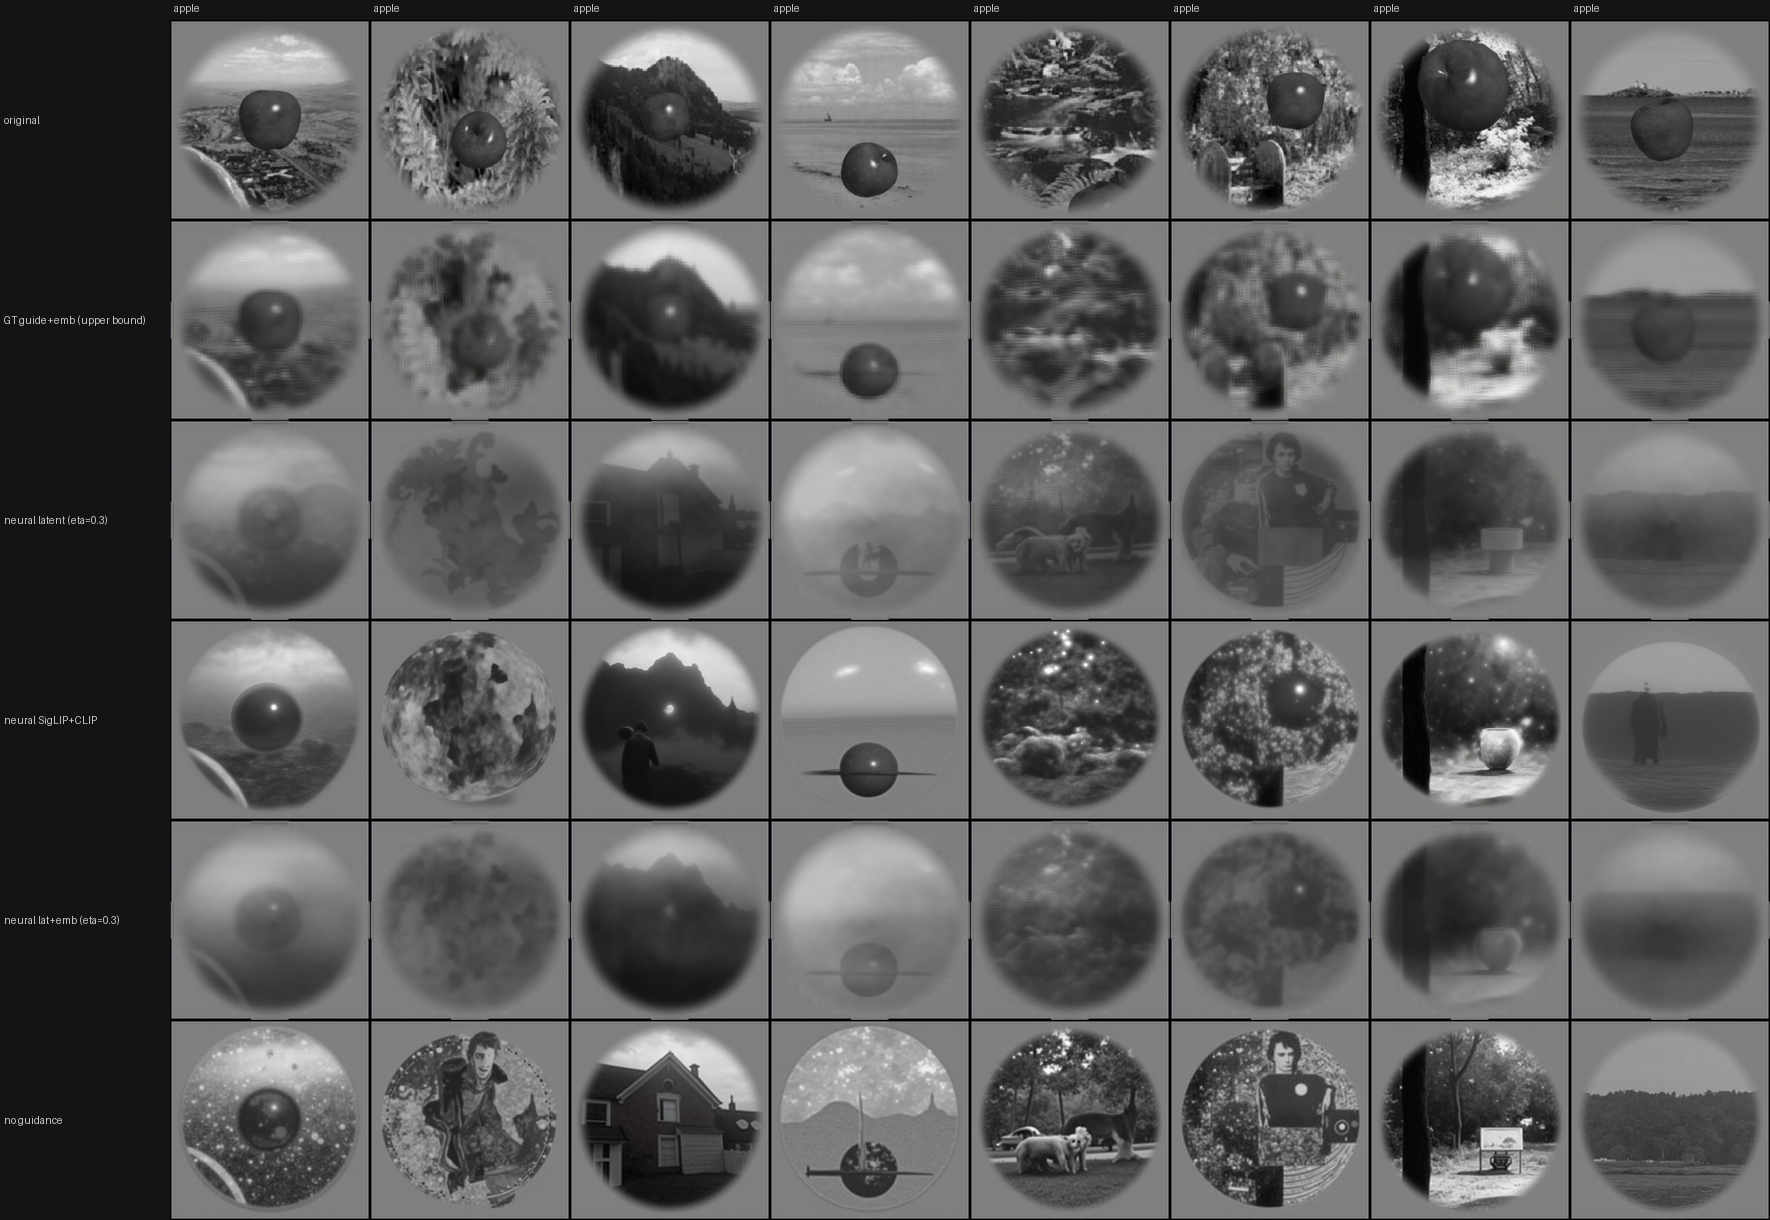

In [15]:
STRENGTH       = 0.7   # match generate_hvm.ipynb
GUIDANCE_ETA   = 0.3
IP_SCALE       = 1.0
NUM_STEPS      = 20
GUIDANCE_SCALE = 7.5    # match generate_hvm.ipynb
N_SHOW         = 8

show_local = list(range(N_SHOW))

# Upsample cached (16,34,34) guidance latents to match IMAGE_SIZE=512 generation.
# 512/8=64 is the spatial size _pack_latents expects at this resolution.
LAT_GEN_HW = IMAGE_SIZE // 8  # 64

def prep_guidance(lat_34):
    up = F.interpolate(lat_34.float(), size=(LAT_GEN_HW, LAT_GEN_HW),
                       mode='bilinear', align_corners=False)
    return up.to(pipe.vae.device, dtype=pipe.vae.dtype)


def decode_lat(latent_4d):
    if latent_4d.dim() == 3:
        latent_4d = latent_4d.unsqueeze(0)
    return decode_latent(pipe, latent_4d.to(pipe.vae.device, dtype=pipe.vae.dtype))


def make_grid(rows_of_pils, col_labels, row_labels=None, thumb=192):
    n_rows = len(rows_of_pils)
    n_cols = len(rows_of_pils[0])
    label_w = 170
    label_h = 20
    grid = Image.new('RGB', (label_w + n_cols * thumb, label_h + n_rows * thumb), (20, 20, 20))
    draw = ImageDraw.Draw(grid)
    for j, lbl in enumerate(col_labels):
        draw.text((label_w + j * thumb + 4, 2), str(lbl), fill=(200, 200, 200))
    for i, row_pils in enumerate(rows_of_pils):
        y0 = label_h + i * thumb
        if row_labels:
            draw.text((4, y0 + thumb // 2 - 6), row_labels[i], fill=(200, 200, 200))
        for j, pil in enumerate(row_pils):
            grid.paste(pil.resize((thumb, thumb), Image.LANCZOS), (label_w + j * thumb, y0))
    return grid


print(f'Generating: IMAGE_SIZE={IMAGE_SIZE}, strength={STRENGTH}, eta={GUIDANCE_ETA}, '
      f'steps={NUM_STEPS}, guidance_scale={GUIDANCE_SCALE}, ip_scale={IP_SCALE}')

rows = {k: [] for k in ['orig', 'gt_guide', 'neural_lat', 'neural_emb', 'neural_lat_emb', 'none']}

for li in show_local:
    orig_pil = stim_pils_test[li].convert('RGB')

    gt_guide     = prep_guidance(gt_latents_test[li].unsqueeze(0))
    neural_guide = prep_guidance(pred_full[li].unsqueeze(0))

    sig_gt    = siglip_test[li]
    clip_gt   = clip_test[li].unsqueeze(0)
    sig_pred  = pred_siglip_test[li]
    clip_pred = pred_clip_test[li].unsqueeze(0)

    common = dict(
        strength=STRENGTH,
        height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS,
        guidance_scale=GUIDANCE_SCALE,
        guidance_eta=GUIDANCE_ETA,
        seed=42,
        aperture_mask=hvm_aperture,
        show_progress=False,
    )

    rows['gt_guide'].append(generate_img2img(
        pipe, image_proj, orig_pil, sig_gt,
        ip_adapter_scale=IP_SCALE,
        prompt_embeds=null_t5, pooled_prompt_embeds=clip_gt,
        guidance_latent=gt_guide, **common,
    ))
    rows['neural_lat'].append(generate_img2img(
        pipe, image_proj, orig_pil, zero_siglip,
        ip_adapter_scale=0.0,
        prompt_embeds=null_t5, pooled_prompt_embeds=null_clip,
        guidance_latent=neural_guide, **common,
    ))
    rows['neural_emb'].append(generate_img2img(
        pipe, image_proj, orig_pil, sig_pred,
        ip_adapter_scale=IP_SCALE,
        prompt_embeds=null_t5, pooled_prompt_embeds=clip_pred,
        **common,
    ))
    rows['neural_lat_emb'].append(generate_img2img(
        pipe, image_proj, orig_pil, sig_pred,
        ip_adapter_scale=IP_SCALE,
        prompt_embeds=null_t5, pooled_prompt_embeds=clip_pred,
        guidance_latent=neural_guide, **common,
    ))
    rows['none'].append(generate_img2img(
        pipe, image_proj, orig_pil, zero_siglip,
        ip_adapter_scale=0.0,
        prompt_embeds=null_t5, pooled_prompt_embeds=null_clip,
        **common,
    ))
    rows['orig'].append(orig_pil)
    print(f'  [{li+1}/{N_SHOW}] done')

cats = [all_stim_paths[test_idx_np[li]].parent.name for li in show_local]

grid = make_grid(
    [rows['orig'], rows['gt_guide'], rows['neural_lat'],
     rows['neural_emb'], rows['neural_lat_emb'], rows['none']],
    col_labels=cats,
    row_labels=[
        'original',
        f'GT guide+emb (upper bound)',
        f'neural latent (eta={GUIDANCE_ETA})',
        'neural SigLIP+CLIP',
        f'neural lat+emb (eta={GUIDANCE_ETA})',
        'no guidance',
    ],
    thumb=200,
)
grid

## Direct latent decode (no denoising)

Decode the neural-predicted latent directly through the VAE decoder — no diffusion denoising at all.
This shows the raw content encoded by the predicted latent before any generation refinement.

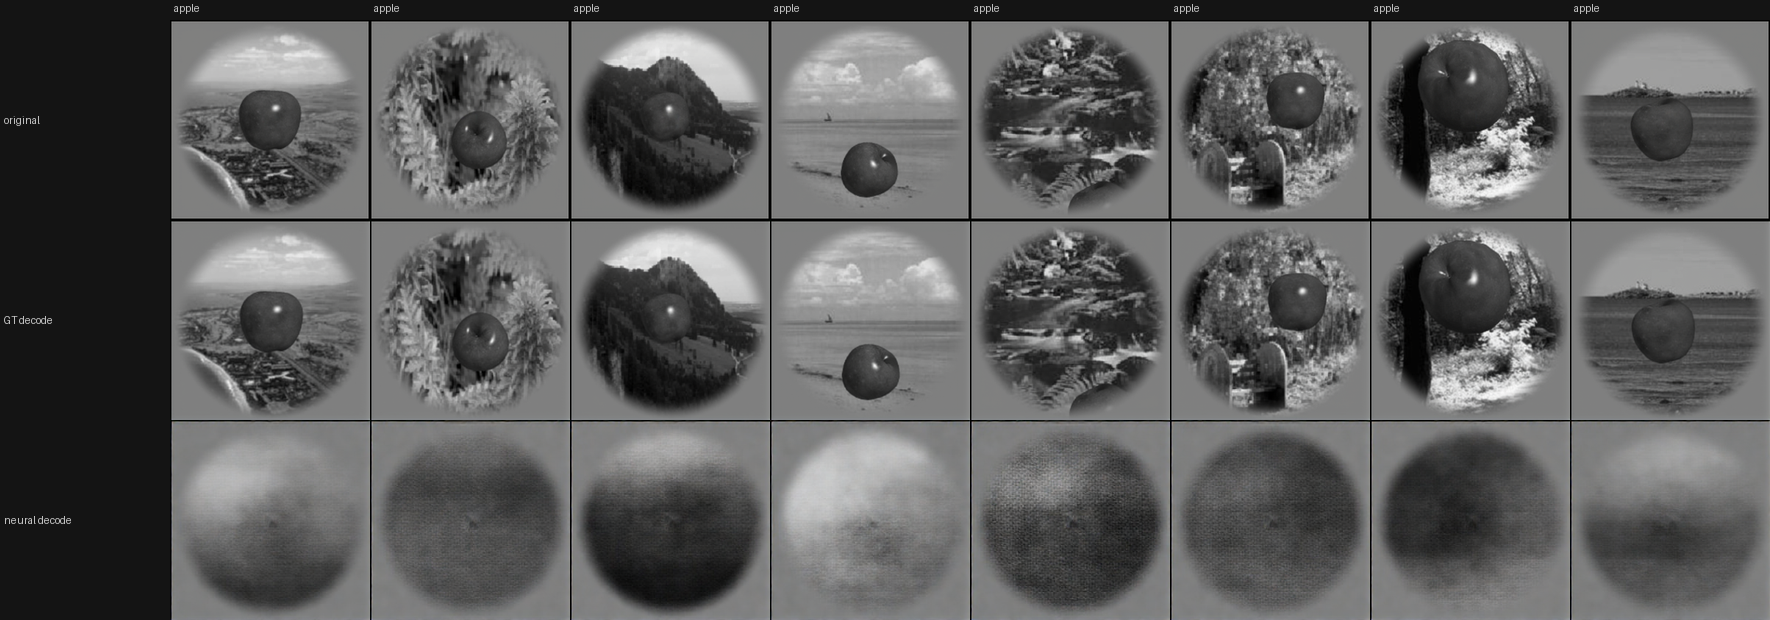

In [16]:
row_gt_decode     = []
row_neural_decode = []
row_orig_decode   = []

for li in show_local:
    orig_pil = stim_pils_test[li].convert('RGB')
    gt_lat     = gt_latents_test[li].unsqueeze(0).to(pipe.vae.device, dtype=pipe.vae.dtype)
    neural_lat = pred_full[li].unsqueeze(0).to(pipe.vae.device, dtype=pipe.vae.dtype)

    row_orig_decode.append(orig_pil)
    row_gt_decode.append(decode_lat(gt_lat))
    row_neural_decode.append(decode_lat(neural_lat))

grid_decode = make_grid(
    [row_orig_decode, row_gt_decode, row_neural_decode],
    col_labels=cats,
    row_labels=['original', 'GT decode', 'neural decode'],
    thumb=200,
)
grid_decode

## Quantitative metrics

For each test stimulus, compute pixel-space luminance MSE between the original and each reconstruction condition.

Condition                mean MSE      std
--------------------------------------------
GT guide+emb                218.8    105.4
neural lat+emb              711.7    314.1
neural latent               719.1    317.8
neural emb                  305.7    163.2
no guidance                 390.0    204.9


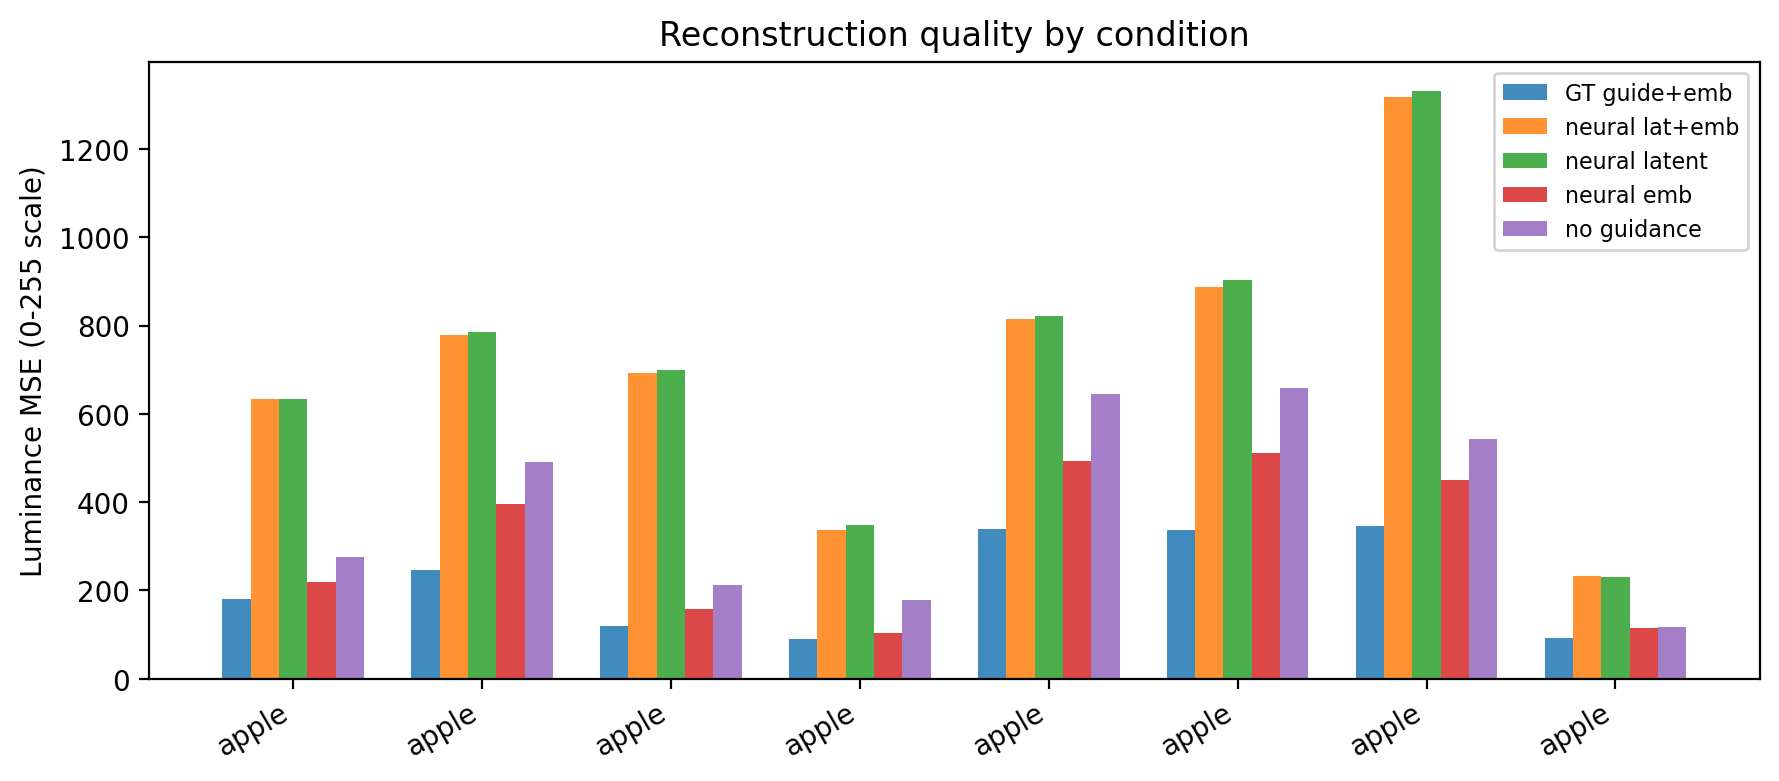

In [17]:
import matplotlib.pyplot as plt

def lum_mse(orig_pil, rec_pil):
    size = orig_pil.size
    a = np.array(orig_pil.resize(size, Image.LANCZOS).convert('L'), dtype=float)
    b = np.array(rec_pil.resize(size, Image.LANCZOS).convert('L'), dtype=float)
    return ((a - b) ** 2).mean()

conditions = [
    ('GT guide+emb',    rows['gt_guide']),
    ('neural lat+emb',  rows['neural_lat_emb']),
    ('neural latent',   rows['neural_lat']),
    ('neural emb',      rows['neural_emb']),
    ('no guidance',     rows['none']),
]

print(f"{'Condition':<22} {'mean MSE':>10} {'std':>8}")
print('-' * 44)
mse_data = {}
for label, rec_list in conditions:
    mses = [lum_mse(rows['orig'][i], rec_list[i]) for i in range(N_SHOW)]
    mse_data[label] = mses
    print(f'{label:<22} {np.mean(mses):10.1f} {np.std(mses):8.1f}')

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(N_SHOW)
w = 0.15
for k, (label, _) in enumerate(conditions):
    ax.bar(x + (k - 2) * w, mse_data[label], w, label=label, alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=30, ha='right')
ax.set_ylabel('Luminance MSE (0-255 scale)')
ax.set_title('Reconstruction quality by condition')
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## Sweep: guidance_eta vs reconstruction quality

How does the RF correction strength affect reconstruction? Low η = guidance barely matters; high η = latent dominates the trajectory.
We compare GT guidance vs neural guidance across several η values at fixed strength.

  stim 0 done
  stim 1 done
  stim 2 done
  stim 3 done


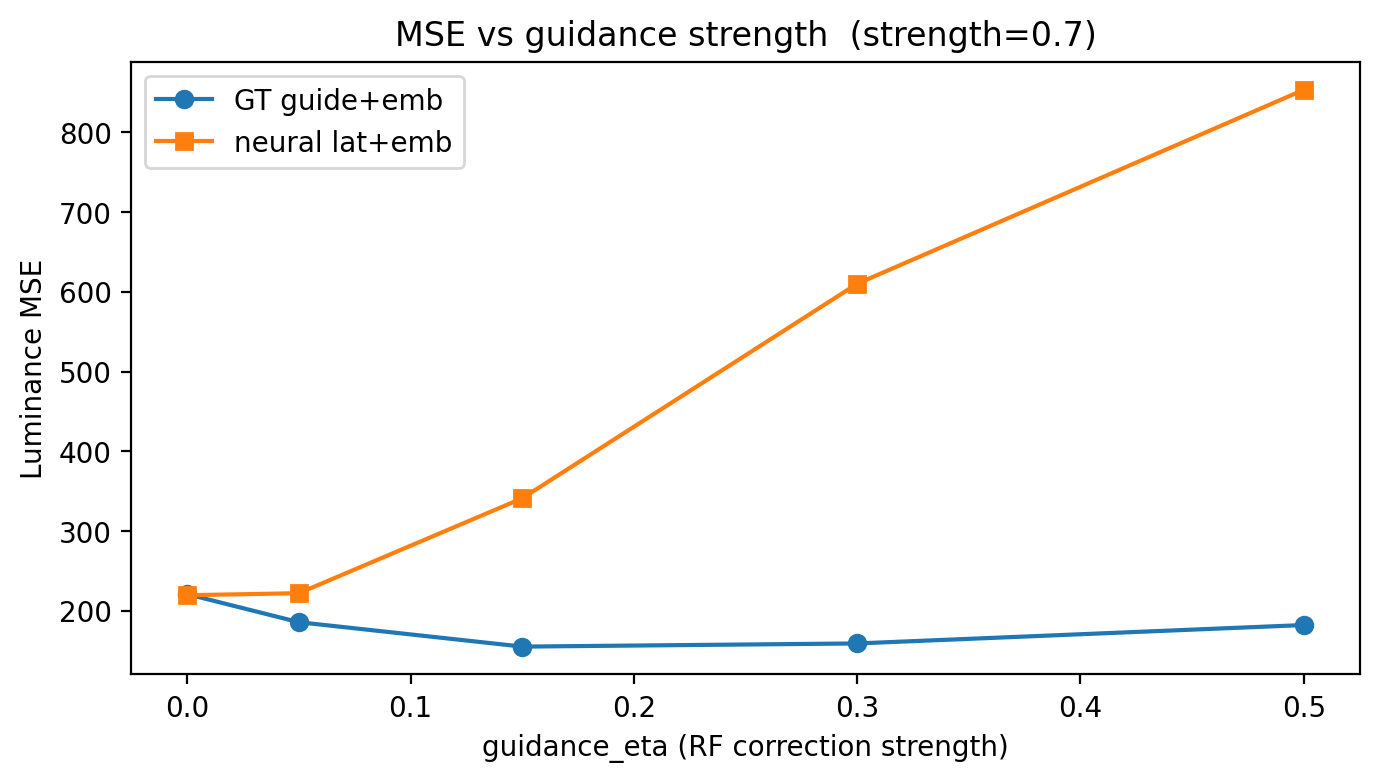

In [18]:
ETAS      = [0.0, 0.05, 0.15, 0.3, 0.5]
SWEEP_IDX = show_local[:4]

mse_by_eta_gt     = {eta: [] for eta in ETAS}
mse_by_eta_neural = {eta: [] for eta in ETAS}

for li in SWEEP_IDX:
    orig_pil     = stim_pils_test[li].convert('RGB')
    gt_guide     = prep_guidance(gt_latents_test[li].unsqueeze(0))
    neural_guide = prep_guidance(pred_full[li].unsqueeze(0))
    sig_gt    = siglip_test[li]
    clip_gt   = clip_test[li].unsqueeze(0)
    sig_pred  = pred_siglip_test[li]
    clip_pred = pred_clip_test[li].unsqueeze(0)

    for eta in ETAS:
        common = dict(
            strength=STRENGTH, height=IMAGE_SIZE, width=IMAGE_SIZE,
            num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE_SCALE,
            guidance_eta=eta, seed=42,
            aperture_mask=hvm_aperture, show_progress=False,
        )
        rec_gt = generate_img2img(
            pipe, image_proj, orig_pil, sig_gt,
            ip_adapter_scale=IP_SCALE,
            prompt_embeds=null_t5, pooled_prompt_embeds=clip_gt,
            guidance_latent=gt_guide, **common,
        )
        rec_neural = generate_img2img(
            pipe, image_proj, orig_pil, sig_pred,
            ip_adapter_scale=IP_SCALE,
            prompt_embeds=null_t5, pooled_prompt_embeds=clip_pred,
            guidance_latent=neural_guide, **common,
        )
        mse_by_eta_gt[eta].append(lum_mse(orig_pil, rec_gt))
        mse_by_eta_neural[eta].append(lum_mse(orig_pil, rec_neural))
    print(f'  stim {li} done')

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ETAS, [np.mean(mse_by_eta_gt[e])     for e in ETAS], 'o-', label='GT guide+emb')
ax.plot(ETAS, [np.mean(mse_by_eta_neural[e]) for e in ETAS], 's-', label='neural lat+emb')
ax.set_xlabel('guidance_eta (RF correction strength)')
ax.set_ylabel('Luminance MSE')
ax.set_title(f'MSE vs guidance strength  (strength={STRENGTH})')
ax.legend()
fig.tight_layout()
plt.show()

## All test stimuli: neural-predicted vs GT init

Scatter of per-stimulus pixel MSE: neural init vs GT init. Points below the diagonal mean neural-init beats GT-init (shouldn't happen often). Points well above the diagonal show where the neural prediction is most off.

  10/30
  20/30
  30/30


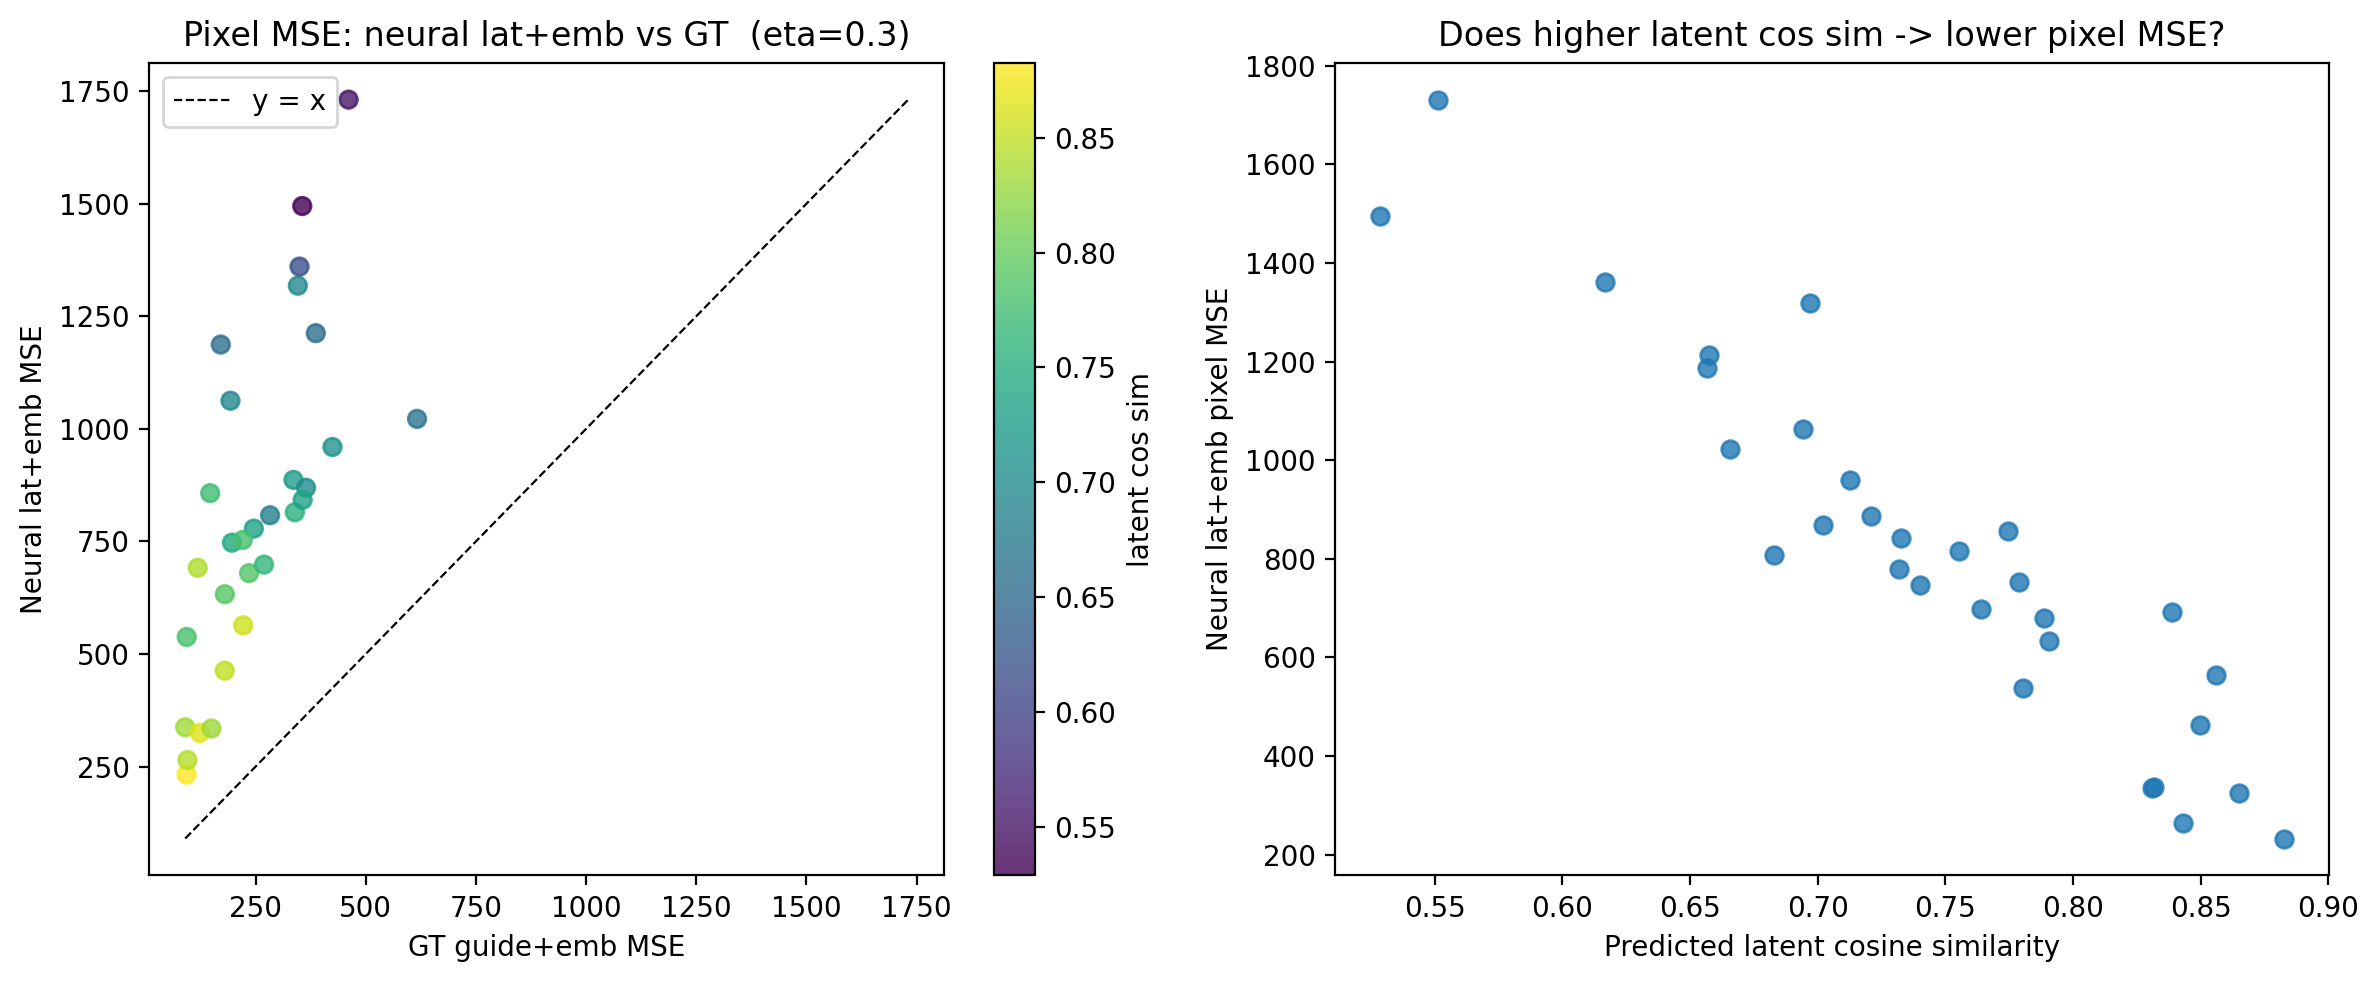


Summary over 30 test stimuli (eta=0.3, strength=0.7):
  GT guide+emb   MSE: 254.9 +/- 125.8
  Neural lat+emb MSE: 815.7 +/- 364.2
  Latent cos sim:     0.7440 +/- 0.0881


In [19]:
N_ALL = 30
all_mse_gt     = []
all_mse_neural = []
all_cos        = []

for li in range(N_ALL):
    orig_pil     = stim_pils_test[li].convert('RGB')
    gt_guide     = prep_guidance(gt_latents_test[li].unsqueeze(0))
    neural_guide = prep_guidance(pred_full[li].unsqueeze(0))
    sig_gt    = siglip_test[li]
    clip_gt   = clip_test[li].unsqueeze(0)
    sig_pred  = pred_siglip_test[li]
    clip_pred = pred_clip_test[li].unsqueeze(0)

    common = dict(
        strength=STRENGTH, height=IMAGE_SIZE, width=IMAGE_SIZE,
        num_inference_steps=NUM_STEPS, guidance_scale=GUIDANCE_SCALE,
        guidance_eta=GUIDANCE_ETA, seed=42,
        aperture_mask=hvm_aperture, show_progress=False,
    )
    rec_gt = generate_img2img(
        pipe, image_proj, orig_pil, sig_gt,
        ip_adapter_scale=IP_SCALE,
        prompt_embeds=null_t5, pooled_prompt_embeds=clip_gt,
        guidance_latent=gt_guide, **common,
    )
    rec_neural = generate_img2img(
        pipe, image_proj, orig_pil, sig_pred,
        ip_adapter_scale=IP_SCALE,
        prompt_embeds=null_t5, pooled_prompt_embeds=clip_pred,
        guidance_latent=neural_guide, **common,
    )
    all_mse_gt.append(lum_mse(orig_pil, rec_gt))
    all_mse_neural.append(lum_mse(orig_pil, rec_neural))
    all_cos.append(cos_full[li].item())
    if (li + 1) % 10 == 0:
        print(f'  {li+1}/{N_ALL}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
sc = ax.scatter(all_mse_gt, all_mse_neural, c=all_cos, cmap='viridis', s=40, alpha=0.8)
lo = min(min(all_mse_gt), min(all_mse_neural))
hi = max(max(all_mse_gt), max(all_mse_neural))
ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, label='y = x')
ax.set_xlabel('GT guide+emb MSE')
ax.set_ylabel('Neural lat+emb MSE')
ax.set_title(f'Pixel MSE: neural lat+emb vs GT  (eta={GUIDANCE_ETA})')
plt.colorbar(sc, ax=ax, label='latent cos sim')
ax.legend()

ax = axes[1]
ax.scatter(all_cos, all_mse_neural, s=40, alpha=0.8)
ax.set_xlabel('Predicted latent cosine similarity')
ax.set_ylabel('Neural lat+emb pixel MSE')
ax.set_title('Does higher latent cos sim -> lower pixel MSE?')

fig.tight_layout()
plt.show()

print(f'\nSummary over {N_ALL} test stimuli (eta={GUIDANCE_ETA}, strength={STRENGTH}):')
print(f'  GT guide+emb   MSE: {np.mean(all_mse_gt):.1f} +/- {np.std(all_mse_gt):.1f}')
print(f'  Neural lat+emb MSE: {np.mean(all_mse_neural):.1f} +/- {np.std(all_mse_neural):.1f}')
print(f'  Latent cos sim:     {np.mean(all_cos):.4f} +/- {np.std(all_cos):.4f}')